In [144]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")


from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    cross_val_predict
)

from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

RANDOM_SEED = 42

In [145]:
df = pd.read_csv('historical_data.csv')


In [146]:
import seaborn as sns
import matplotlib.pyplot as plt


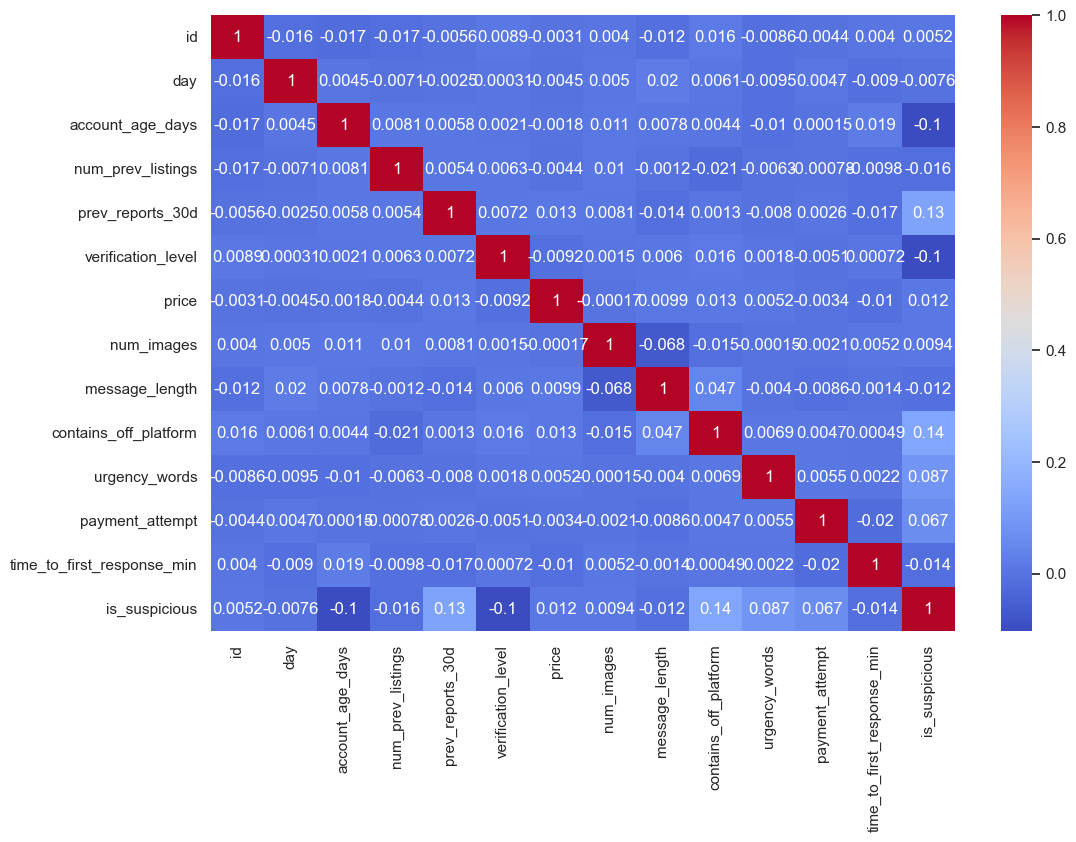

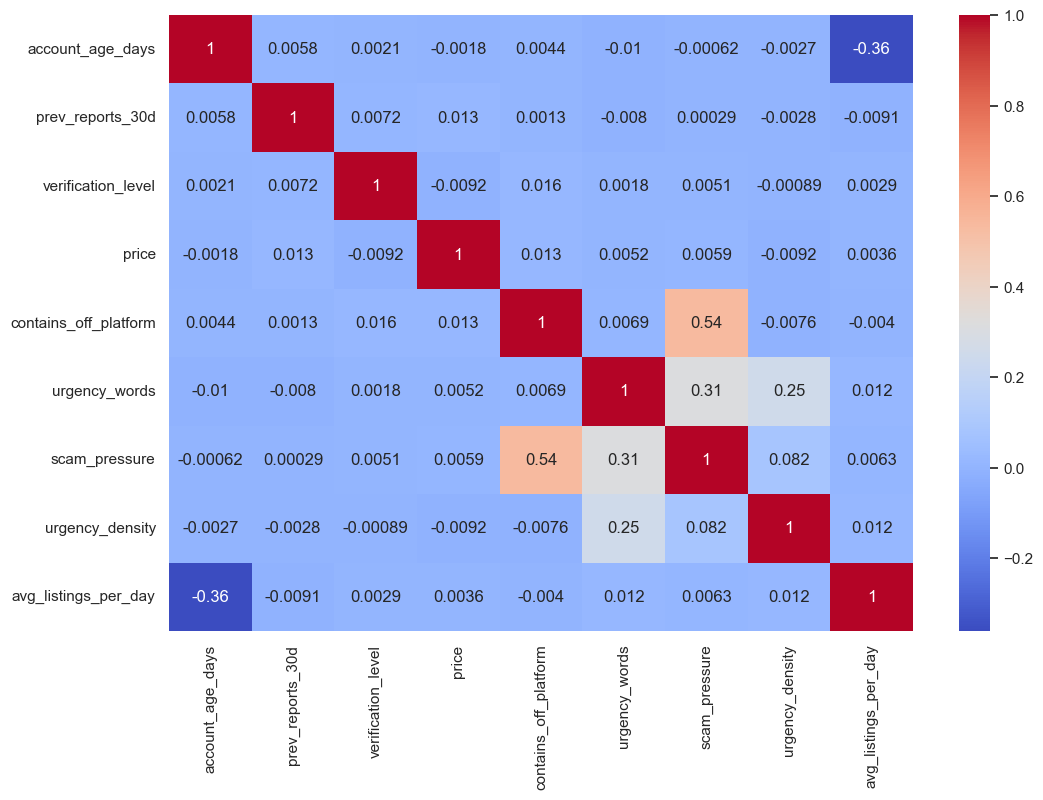

In [147]:

X = df.copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

num_cols = ['day',
            'account_age_days',
            'num_prev_listings',
            'prev_reports_30d',
            'verification_level',
            'price', 
            'num_images',
            'message_length',
            'contains_off_platform',
            'urgency_words',
            'payment_attempt',
            'time_to_first_response_min'
            "trust_score",
            "avg_listings_per_day",
            "urgency_density",
            "reports_per_listing",
            "fast_response_urgency",
            "activity",
            "report_ratio",
            "scam_pressure"
            ]

cat_cols = ['event_type', 'category', 'region', 'device']

# Skapar nya features och testar dom för att se om resultatet blir bättre

X["scam_pressure"] = (
    df["urgency_words"] +
    df["contains_off_platform"] * 2 +
    df["payment_attempt"] * 2
)
#X["report_ratio"] = df["prev_reports_30d"] / (df["num_prev_listings"] + 1)
#X["fast_response_urgency"] = df["urgency_words"] / (df["time_to_first_response_min"] + 1)
#X["reports_per_listing"] = df["prev_reports_30d"] / (df["num_prev_listings"] + 1)
X["urgency_density"] = df["urgency_words"] / (df["message_length"] + 1)
#X["trust_score"] = df["verification_level"] * np.log(df["account_age_days"] + 1)
X["avg_listings_per_day"] = df["num_prev_listings"] / (df["account_age_days"] + 1)
#X["risk_score"] =((df["prev_reports_30d"] * 2) +(df["contains_off_platform"] * 3) +(df["payment_attempt"] * 3) +(df["urgency_words"]))
#X["high_verification"] = (df["verification_level"] >= 2).astype(int)
#X["prev_reports_30d_fraud_rate"] = df["prev_reports_30d"].map(
    #df.groupby("prev_reports_30d")["is_suspicious"].mean())
#X["off_platform_rate"] = df["contains_off_platform"].map(
#    df.groupby("contains_off_platform")["is_suspicious"].mean())


# Tar bort features jag inte vill ha

drop_columns = [
    "is_suspicious", "id",'event_type', 'category', 'region','device',
    'num_images', "day", 'num_prev_listings','message_length',
    'time_to_first_response_min', 'payment_attempt'
    ]


X = X.drop(columns= drop_columns)
y = df['is_suspicious'].copy()

# lägger alla använda features i en lista för senare använding i pipeline

columns_used = [c for c in X.columns if c not in drop_columns]
columns_used

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify=y
)

# Använd om inte K-fold eller cross validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify= y_train
)


X["scam_pressure"].corr(df["is_suspicious"])

np.float64(0.15416671705025578)

In [149]:

num_cols = [x for x in columns_used if x in num_cols]
cat_cols = [x for x in columns_used if x in cat_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])


In [150]:
lr = LogisticRegression(max_iter=200, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED,
        max_depth=5, min_samples_leaf=2, n_jobs=-1, class_weight="balanced")
dt = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")
gb = GradientBoostingClassifier(random_state=RANDOM_SEED)
xgb = XGBClassifier(scale_pos_weight=9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42)

In [151]:
model_lr = make_model(lr)
model_rf = make_model(rf)
model_dt = make_model(dt)
model_gb = make_model(gb)
model_xgb = make_model(xgb)

In [152]:
model_lr.fit(X_tr, y_tr)
model_rf.fit(X_tr, y_tr)
model_dt.fit(X_tr, y_tr)
model_gb.fit(X_tr, y_tr)
model_xgb.fit(X_tr, y_tr)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [153]:
feature_names = model_rf.named_steps["preprocess"].get_feature_names_out()

import pandas as pd

pd.Series(
    model_rf.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

num__account_age_days         0.349742
num__avg_listings_per_day     0.158055
num__scam_pressure            0.141580
num__verification_level       0.110555
num__prev_reports_30d         0.094308
num__contains_off_platform    0.065655
num__price                    0.053803
num__urgency_density          0.020255
num__urgency_words            0.006047
dtype: float64

In [154]:
feature_names = model_gb.named_steps["preprocess"].get_feature_names_out()

import pandas as pd

pd.Series(
    model_gb.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

num__account_age_days         0.316308
num__prev_reports_30d         0.132045
num__avg_listings_per_day     0.115001
num__price                    0.112466
num__scam_pressure            0.096805
num__verification_level       0.090941
num__contains_off_platform    0.079674
num__urgency_density          0.056182
num__urgency_words            0.000579
dtype: float64

In [155]:
feature_names = model_dt.named_steps["preprocess"].get_feature_names_out()

import pandas as pd

pd.Series(
    model_dt.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

num__account_age_days         0.357564
num__price                    0.256011
num__avg_listings_per_day     0.211956
num__scam_pressure            0.053500
num__verification_level       0.044947
num__prev_reports_30d         0.038418
num__urgency_density          0.024665
num__contains_off_platform    0.009340
num__urgency_words            0.003598
dtype: float64

In [156]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "roc_auc"

models = {
    "LogisticRegression": model_lr,
    "RandomForestClassifier": model_rf,
    "DecisionTree": model_dt,
    "GradientBoosting": model_gb,
    "XGBClassifier": model_xgb
}


baseline_rows = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table


,model,mean,std
3,GradientBoosting,0.753015,0.009163
1,RandomForestClassifier,0.750265,0.009552
0,LogisticRegression,0.744452,0.016301
4,XGBClassifier,0.675481,0.013520
2,DecisionTree,0.541568,0.011539


In [157]:
from sklearn.metrics import roc_auc_score

preds = model_rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val, preds)

0.7329833325441546

In [158]:
predicted_y_log_reg = model_lr.predict(X_val)
predicted_y_rf = model_rf.predict(X_val)
predicted_y_dt = model_dt.predict(X_val)
predicted_y_gb= model_gb.predict(X_val)

print(classification_report(y_val, predicted_y_log_reg))
print(classification_report(y_val, predicted_y_rf))
print(classification_report(y_val, predicted_y_dt))
print(classification_report(y_val, predicted_y_gb))

              precision    recall  f1-score   support

           0       0.95      0.71      0.81      1724
           1       0.20      0.65      0.31       196

    accuracy                           0.70      1920
   macro avg       0.58      0.68      0.56      1920
weighted avg       0.87      0.70      0.76      1920

              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1724
           1       0.19      0.60      0.29       196

    accuracy                           0.69      1920
   macro avg       0.56      0.65      0.54      1920
weighted avg       0.86      0.69      0.75      1920

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1724
           1       0.19      0.17      0.18       196

    accuracy                           0.84      1920
   macro avg       0.55      0.55      0.55      1920
weighted avg       0.83      0.84      0.84      1920

              preci